/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Forecast price for 1/1/2025 (Linear Regression): 8.18
Forecast price for 1/1/2025 (MA4): 15.99
Forecast price for 1/1/2025 (MA12): 15.61


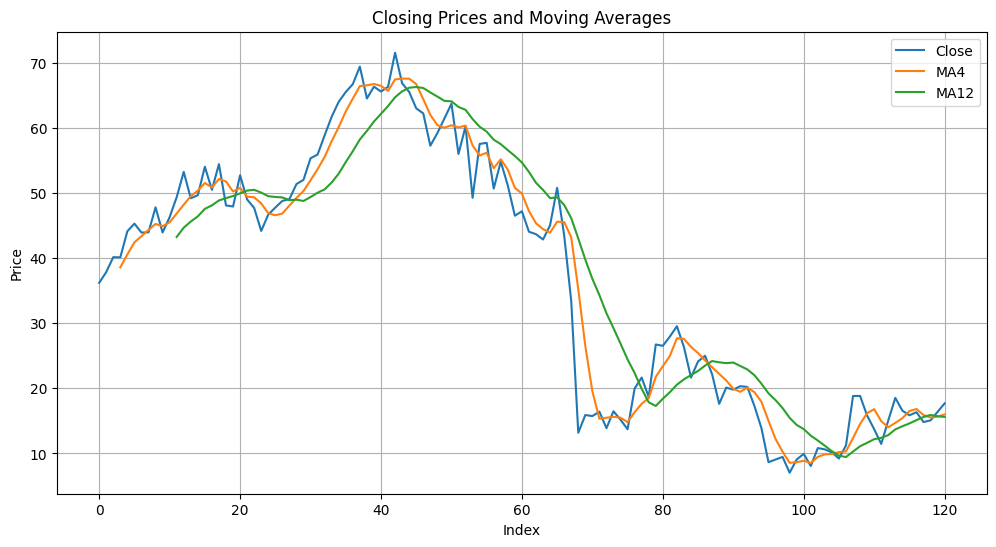

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

data = pd.read_excel("/Forcast Prices.xlsx")

# Create time index
data["Index"] = range(1, len(data)+1)

# Moving averages
data["MA4"] = data["Close"].rolling(4).mean()
data["MA12"] = data["Close"].rolling(12).mean()

# Regression model
X = data[["Index"]]
y = data["Close"]

model = LinearRegression()
model.fit(X,y)

# Assuming data is monthly and the last entry (Index 121) is June 2024.
# To forecast for 1/1/2025 (January 2025), we need to determine the corresponding Index.
# June 2024 (Index 121) -> July 2024 (122) -> ... -> Jan 2025 (128)
index_for_2025_01_01 = len(data) + 7

# 1. Forecast the closing price for 1/1/25 using simple linear regression
forecast_lr_2025_01_01 = model.predict([[index_for_2025_01_01]])
print(f"Forecast price for 1/1/2025 (Linear Regression): {forecast_lr_2025_01_01[0]:.2f}")

# 2. Forecast the closing price for 1/1/25 using moving average of 4 periods
# For future forecasts with MA, we typically use the last calculated MA value.
forecast_ma4_2025_01_01 = data["MA4"].iloc[-1]
print(f"Forecast price for 1/1/2025 (MA4): {forecast_ma4_2025_01_01:.2f}")

# 3. Forecast the closing price for 1/1/25 using moving average of 12 periods
forecast_ma12_2025_01_01 = data["MA12"].iloc[-1]
print(f"Forecast price for 1/1/2025 (MA12): {forecast_ma12_2025_01_01:.2f}")

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(data["Close"], label="Close")
plt.plot(data["MA4"], label="MA4")
plt.plot(data["MA12"], label="MA12")
plt.title("Closing Prices and Moving Averages")
plt.xlabel("Index")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

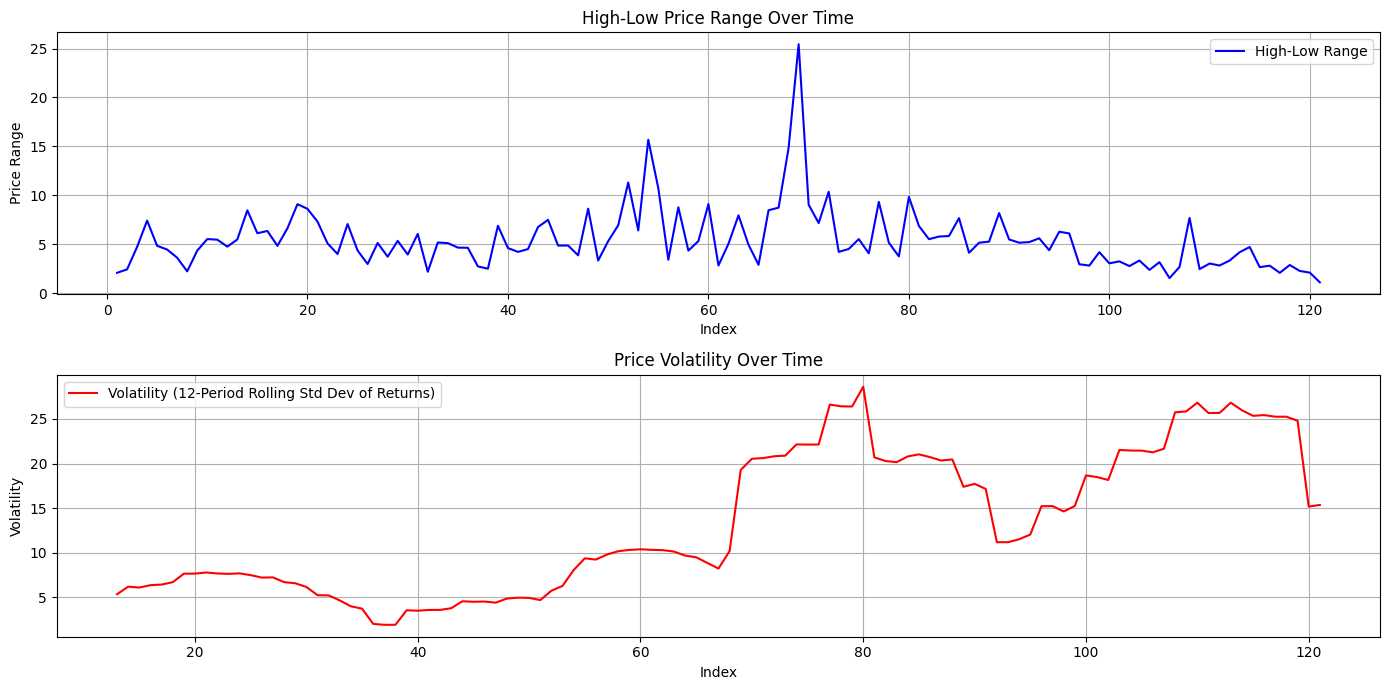

In [8]:
import matplotlib.pyplot as plt

# Calculate High-Low Range
data['High_Low_Range'] = data['High'] - data['Low']

# Calculate daily returns for volatility
data['Daily_Return'] = data['Close'].pct_change() * 100

# Calculate rolling standard deviation of daily returns as a measure of volatility
# Using a 12-period rolling window (e.g., 12 months for monthly data)
data['Volatility_12_Period'] = data['Daily_Return'].rolling(window=12).std()

# Plotting the High-Low Range and Volatility
plt.figure(figsize=(14, 7))

# Plot High-Low Range
plt.subplot(2, 1, 1) # 2 rows, 1 column, first plot
plt.plot(data['Index'], data['High_Low_Range'], label='High-Low Range', color='blue')
plt.title('High-Low Price Range Over Time')
plt.xlabel('Index')
plt.ylabel('Price Range')
plt.legend()
plt.grid(True)

# Plot Volatility (Rolling Standard Deviation of Returns)
plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot
plt.plot(data['Index'], data['Volatility_12_Period'], label='Volatility (12-Period Rolling Std Dev of Returns)', color='red')
plt.title('Price Volatility Over Time')
plt.xlabel('Index')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()